In [1]:
"""
Does not work as intended because of data loading. Consider deleting. See init.ipynb for intended initialization code. 
"""

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

# Bianchi period:
start_date = '1971-08-31'
# end_date = '2018-12-31'

end_date = '2025-06-30' # kr and gsw end date
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# Apply the shared per-series publication lag policy to latest-snapshot macro data
fred_md = bu.apply_fred_md_publication_lag(fred_md_raw)  

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Backfill fred_md to avoid nans
fred_md = fred_md.bfill()

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

y_all = xr[['24','36','48','60','72','84','96','108','120']].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: module 'utils.base_utils' has no attribute 'apply_fred_md_publication_lag'

# Correlation between Macroeconomic variables

<Axes: >

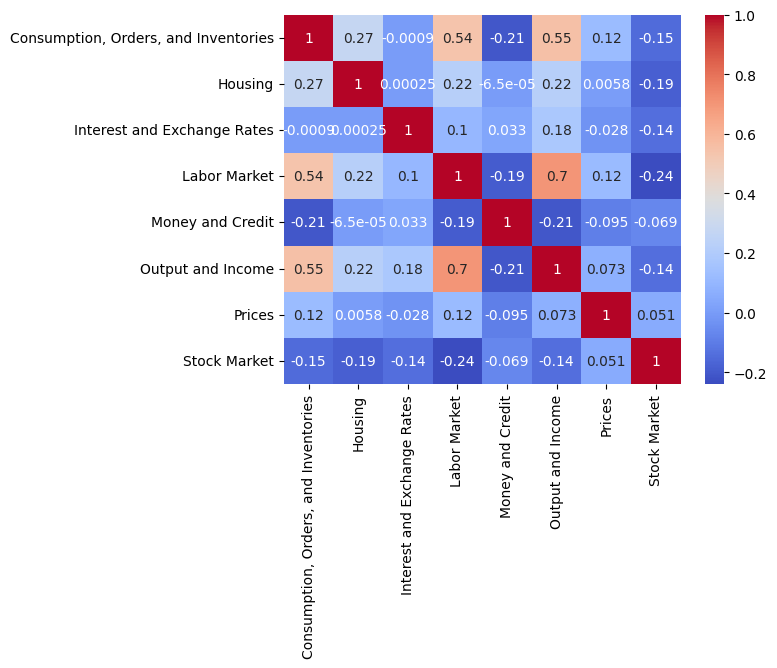

In [2]:
import numpy as np
import pandas as pd

# 1) Take FRED block only (columns are MultiIndex: [group, series])
fred = X["fred"].copy()

# Level with macro categories (usually level 0 after X['fred'])
group_level = 0

# Standardize each individual series over full sample (z-score by column, within each group block)
fred_std = fred.copy()
for g in fred.columns.get_level_values(group_level).unique():
    cols = fred.columns[fred.columns.get_level_values(group_level) == g]
    block = fred.loc[:, cols]
    mu = block.mean(axis=0)
    sd = block.std(axis=0, ddof=0).replace(0, np.nan)  # avoid divide-by-zero
    fred_std.loc[:, cols] = (block - mu) / sd

# Optional: fill constant-series NaNs with 0 after standardization
fred_std = fred_std.fillna(0.0)

# 2) Mean across standardized series within each macro group, per date
group_mean_df = pd.DataFrame({
    g: fred_std.loc[:, fred_std.columns.get_level_values(group_level) == g].mean(axis=1)
    for g in fred_std.columns.get_level_values(group_level).unique()
}, index=fred_std.index)

sns.heatmap(group_mean_df.corr(), annot=True, cmap='coolwarm')

Number of pairwise plots: 28


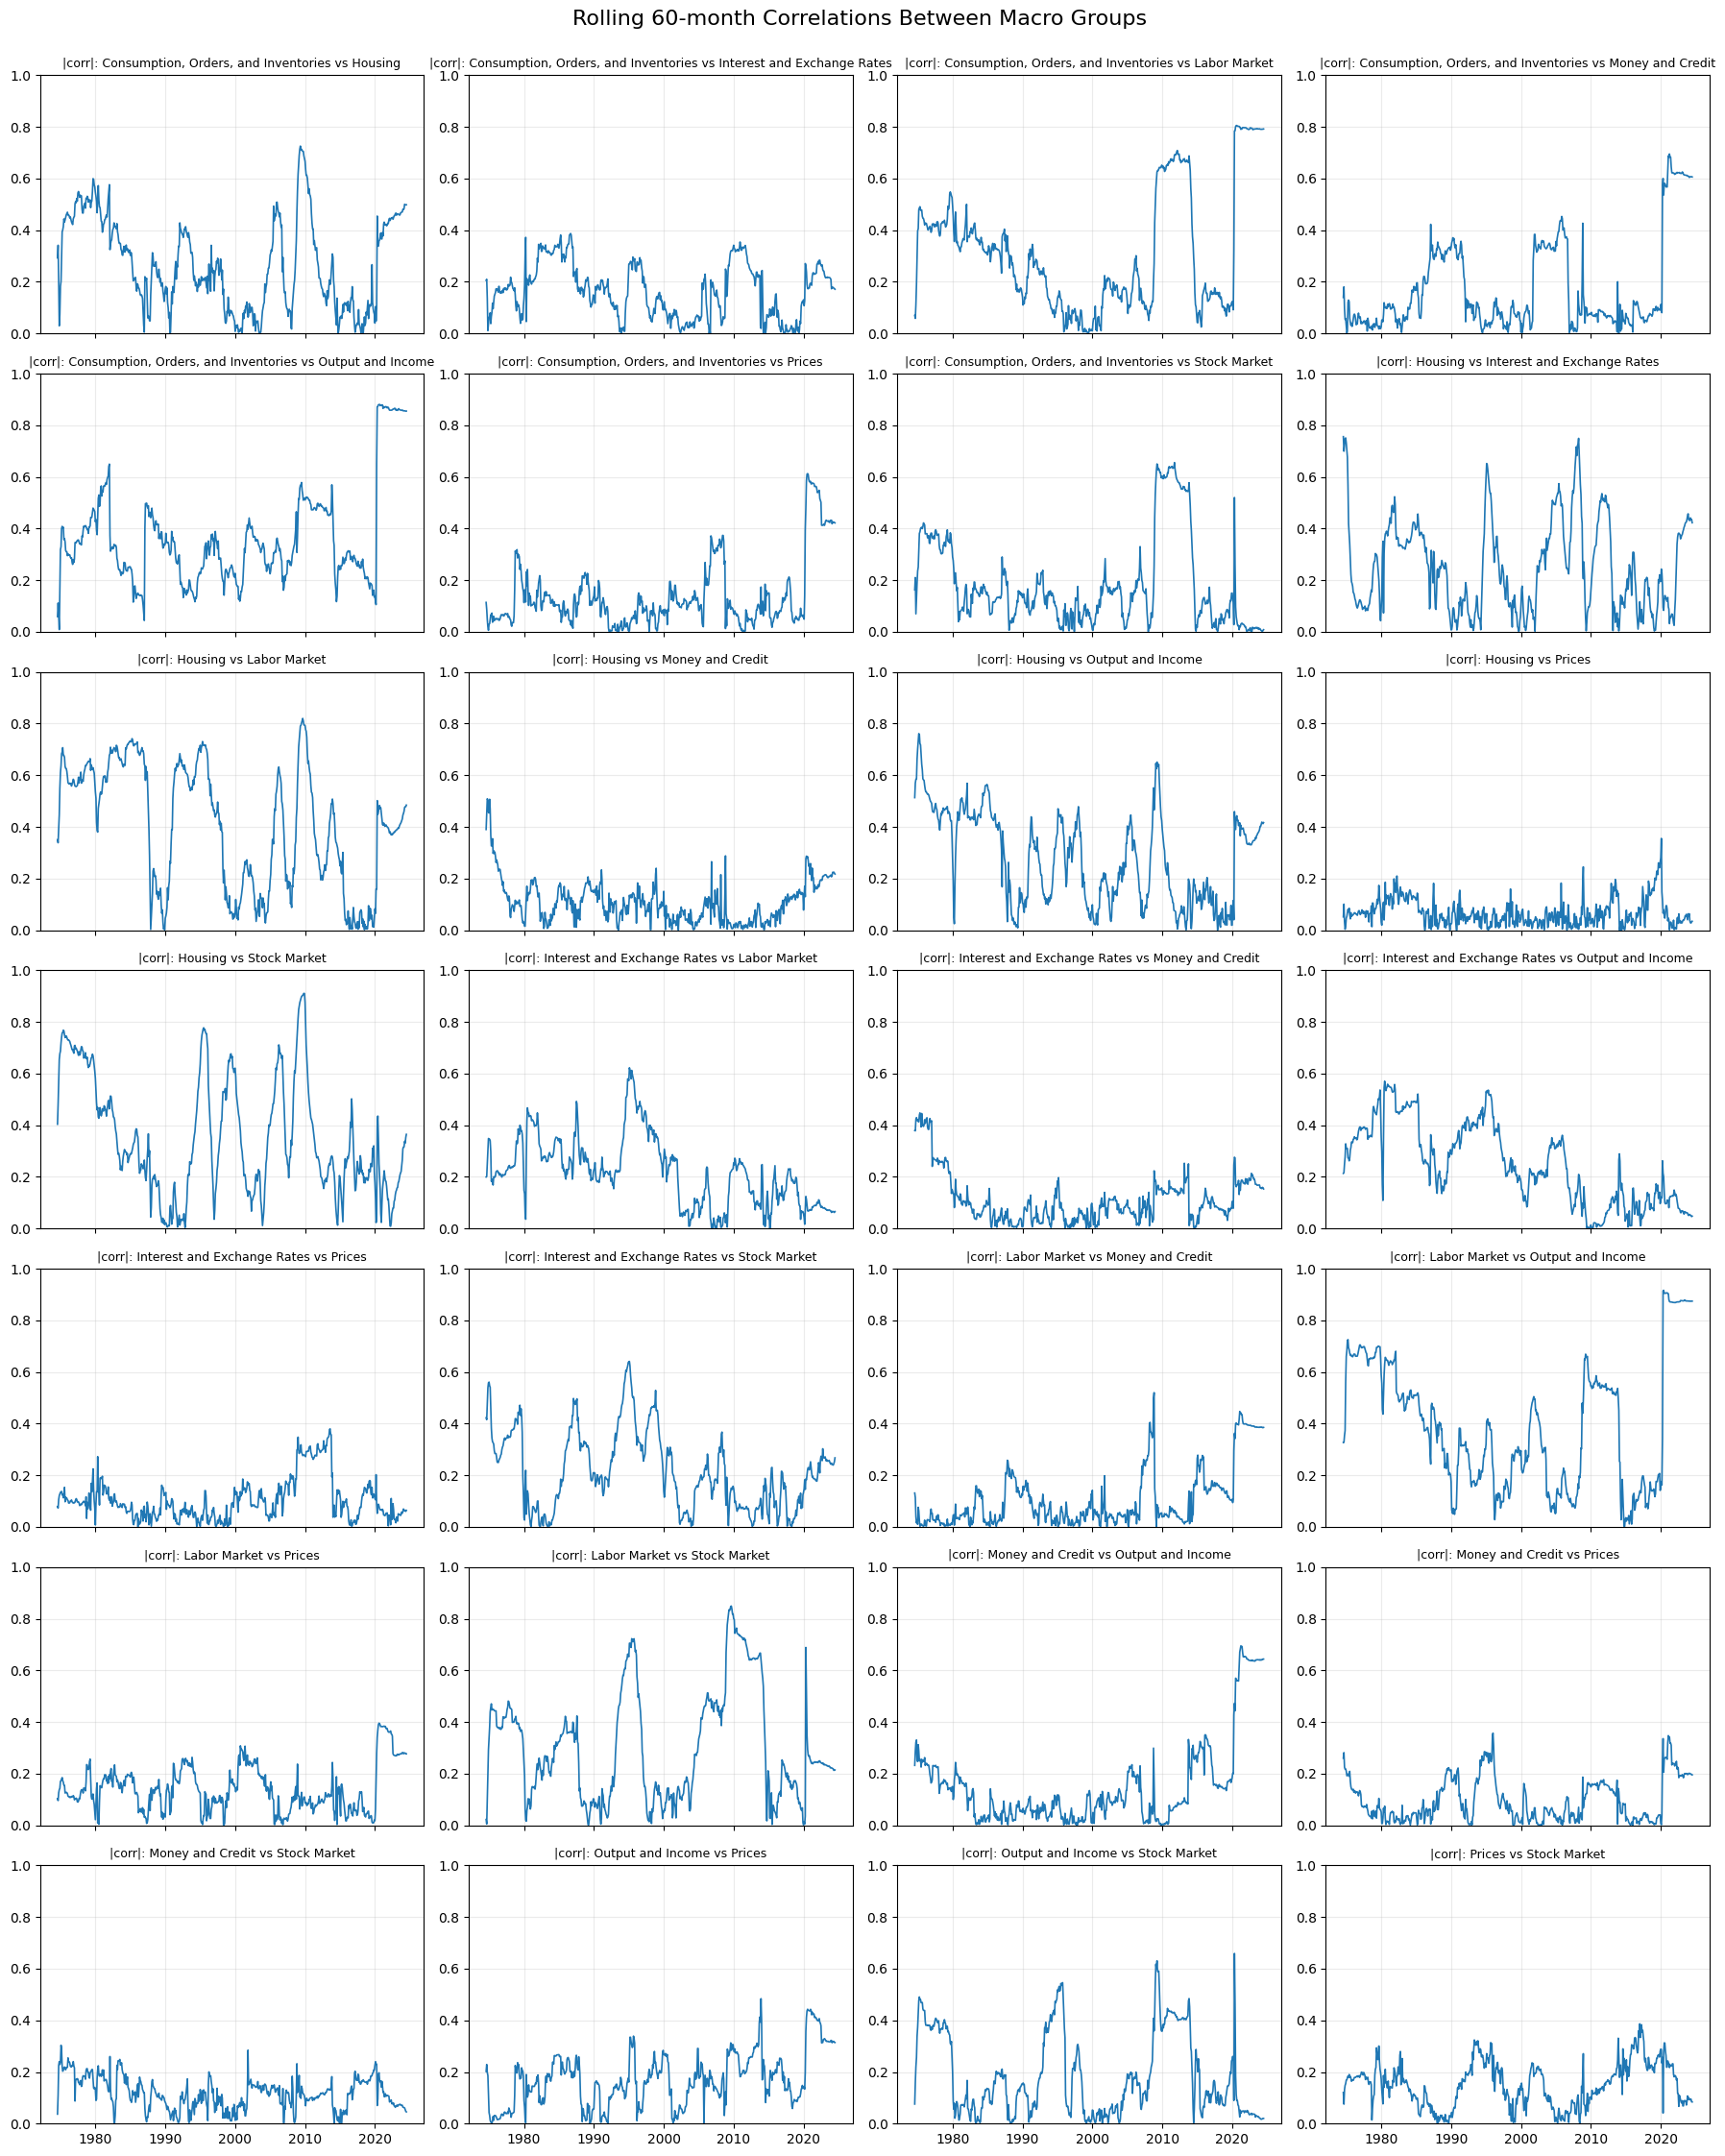

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# group_mean_df: index=date, columns=8 grouped variables
window = 60  # 5 years of monthly data

pairs = list(combinations(group_mean_df.columns, 2))  # 28 pairs
n_plots = len(pairs)
print(f"Number of pairwise plots: {n_plots}")

# Make subplot grid (e.g., 7x4 for 28)
ncols = 4
nrows = int(np.ceil(n_plots / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, (a, b) in enumerate(pairs):
    corr_series = group_mean_df[a].rolling(window=window, min_periods=36).corr(group_mean_df[b]).abs()
    axes[i].plot(corr_series.index, corr_series.values, linewidth=1.2)
    axes[i].set_title(f"|corr|: {a} vs {b}", fontsize=9)
    axes[i].set_ylim(0, 1)
    axes[i].grid(alpha=0.25)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# place title on top center, above all subplots
plt.suptitle(f"Rolling {window}-month Correlations Between Macro Groups", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

# Excess returns:

Monthly:

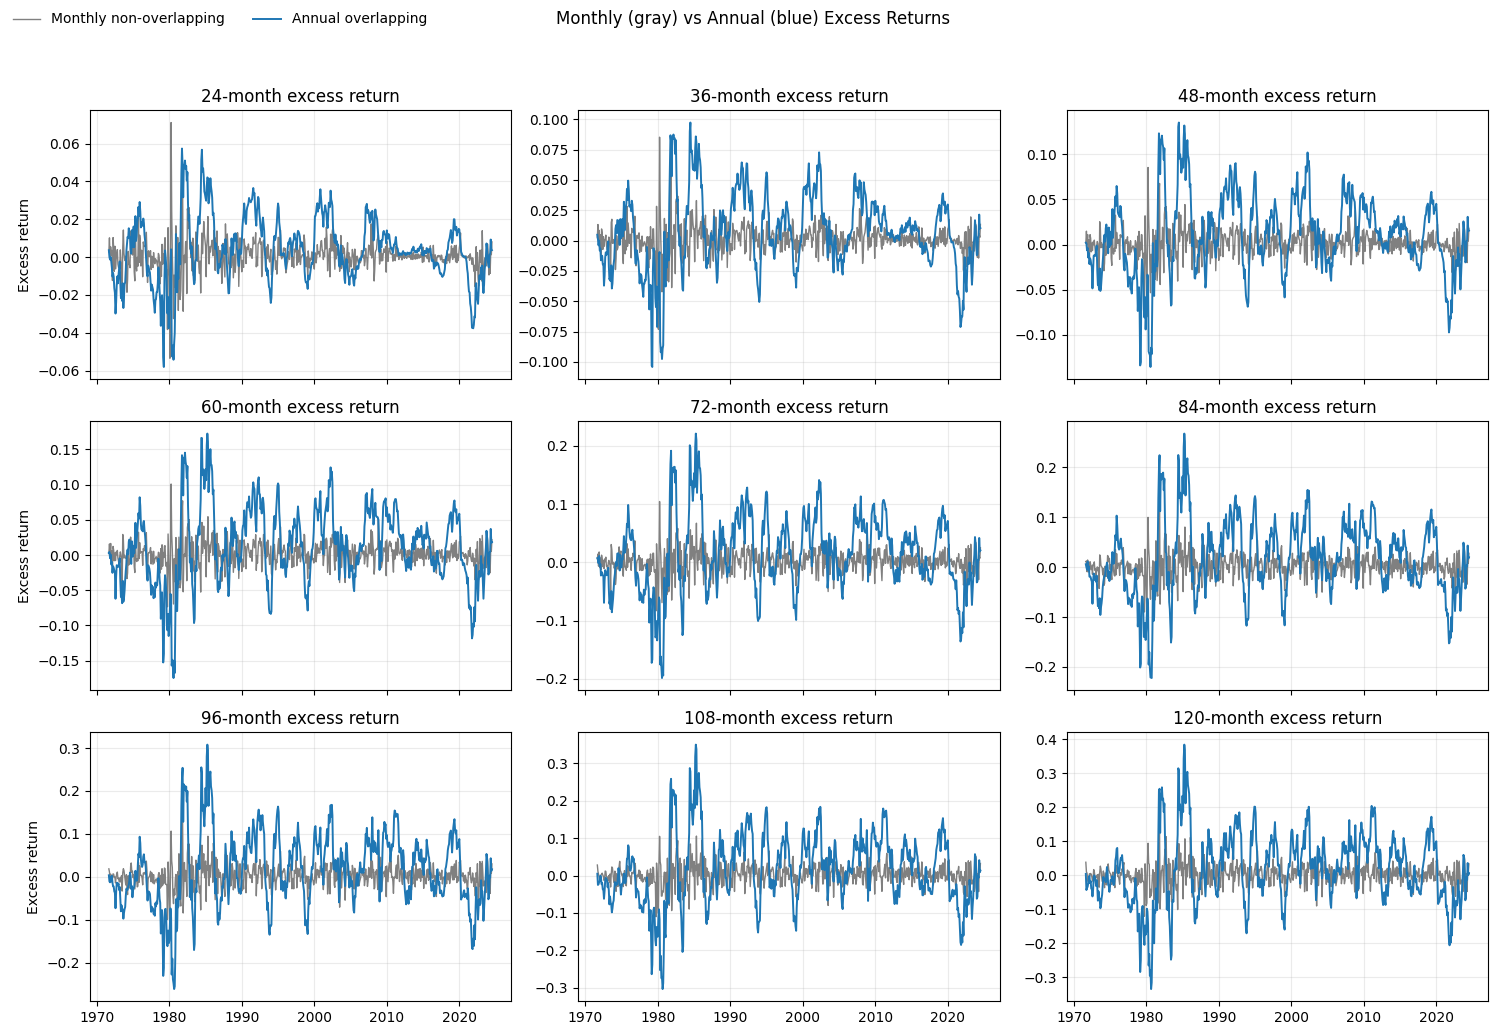

In [10]:
import matplotlib.pyplot as plt

ncols, nrows = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True)
axes = axes.flatten()

# Use the same maturities as annual xr, but keep only those also present in monthly_xr
cols = [c for c in list(xr.columns)[-nrows * ncols:] if c in monthly_xr.columns]

# Align dates to common index for clean overlays
common_idx = xr.index.intersection(monthly_xr.index)

for i, col in enumerate(cols):
    ax = axes[i]
    ax.plot(
        common_idx, monthly_xr.loc[common_idx, col],
        color="gray", linewidth=1.0,
        label="Monthly non-overlapping" if i == 0 else None
    )
    ax.plot(
        common_idx, xr.loc[common_idx, col], linestyle="-", linewidth=1.4,
        label="Annual overlapping" if i == 0 else None
    )
    ax.set_title(f"{col}-month excess return")
    ax.set_xlabel("")
    ax.grid(alpha=0.25)
    ax.set_ylabel("Excess return" if i % ncols == 0 else "")

# Hide unused axes
for j in range(len(cols), len(axes)):
    axes[j].axis("off")

# Single legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=2, frameon=False)

fig.suptitle("Monthly (gray) vs Annual (blue) Excess Returns", y=1.03)
plt.tight_layout()
plt.show()

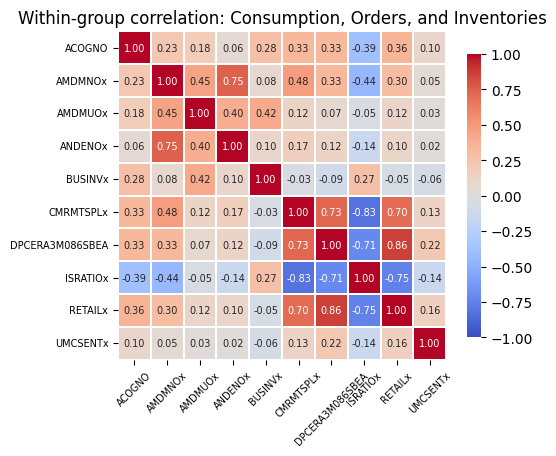

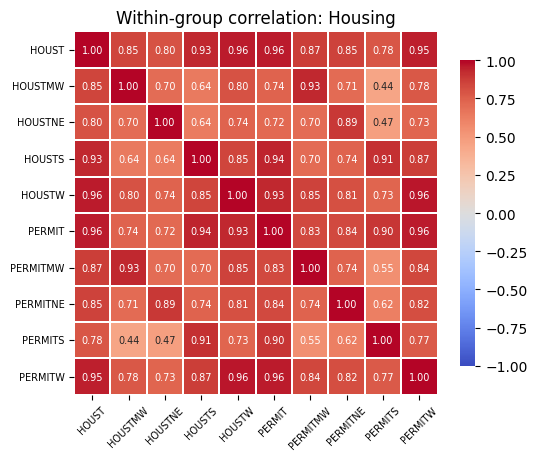

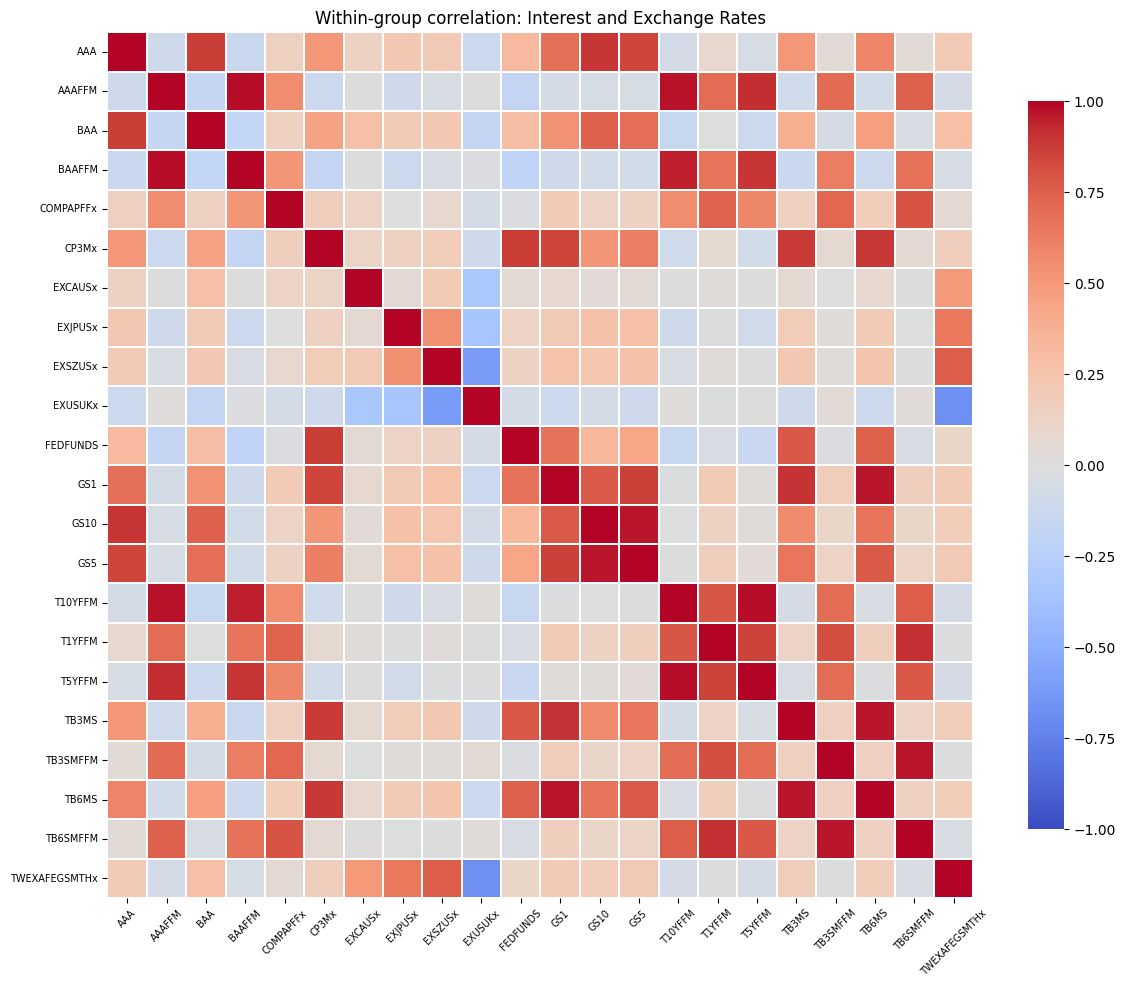

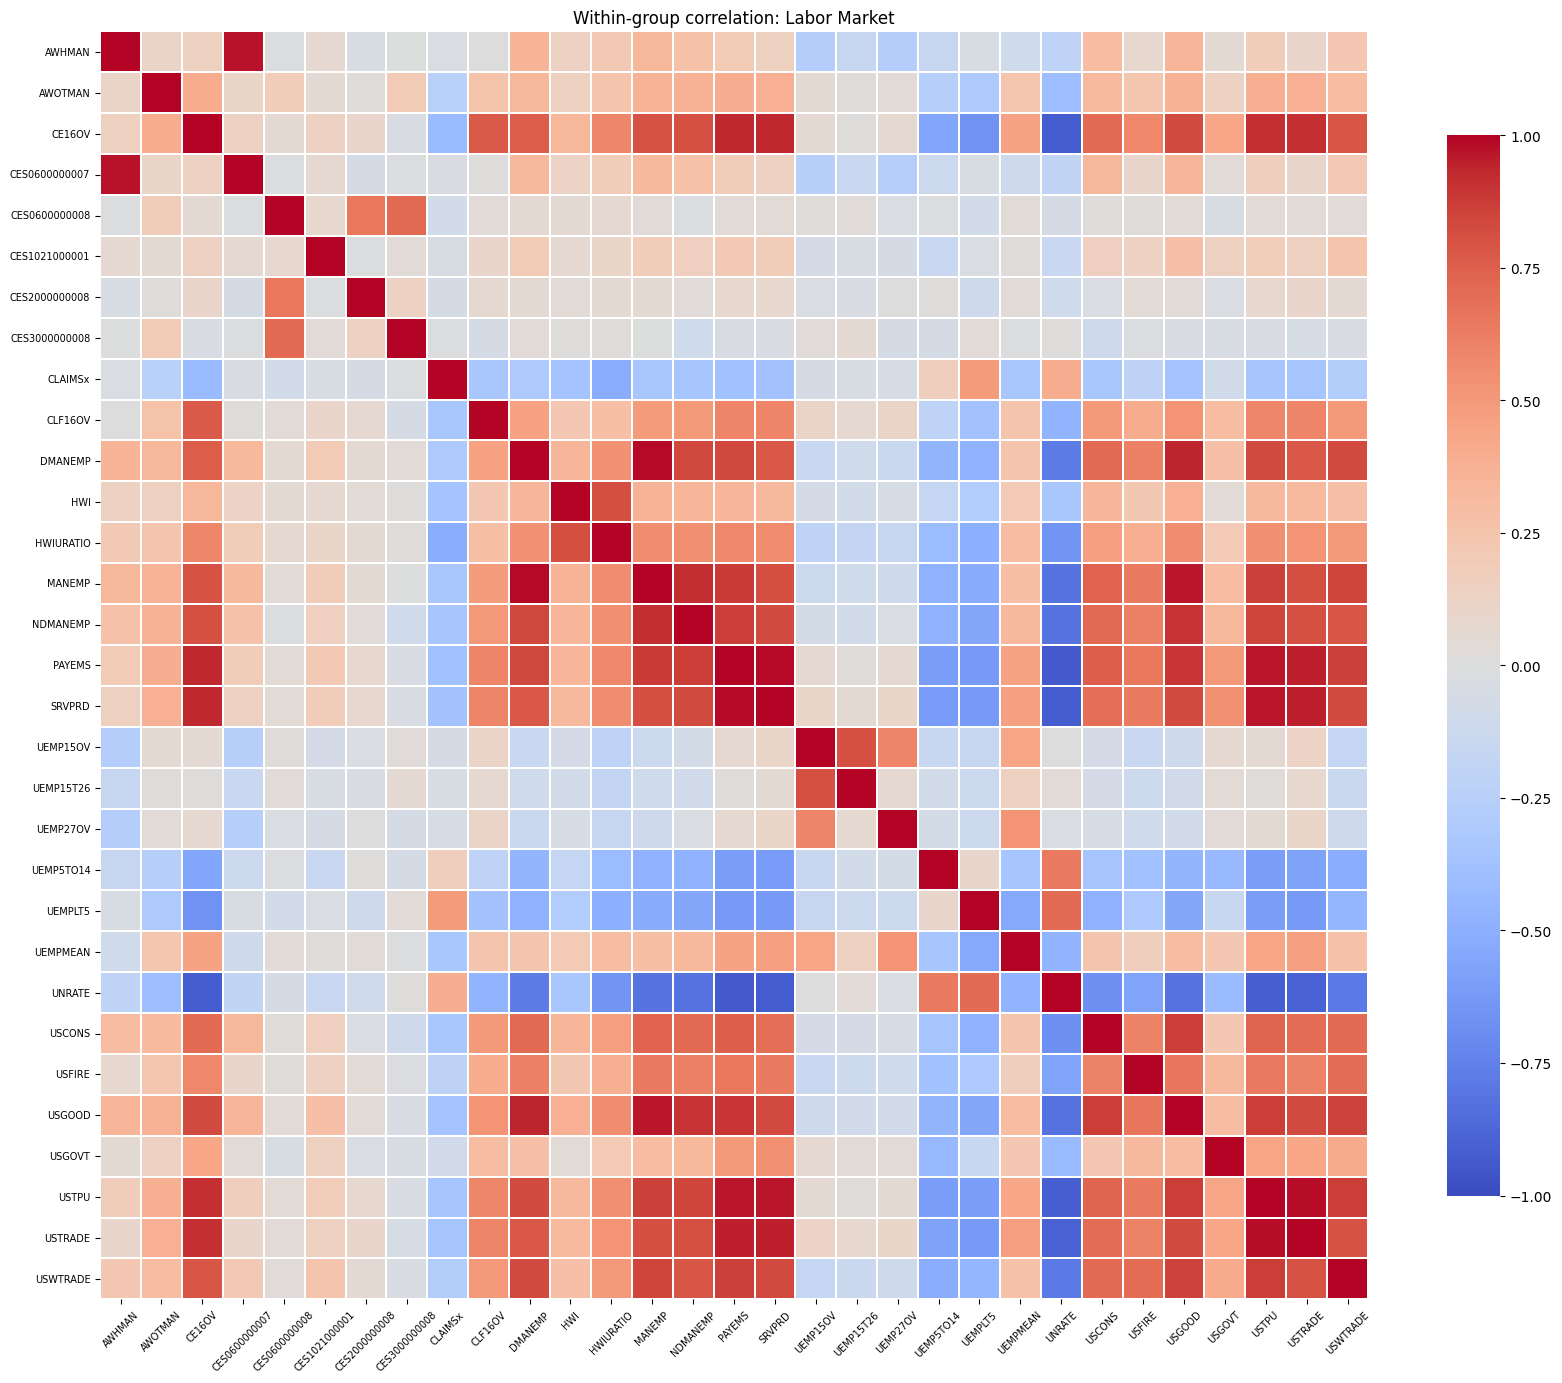

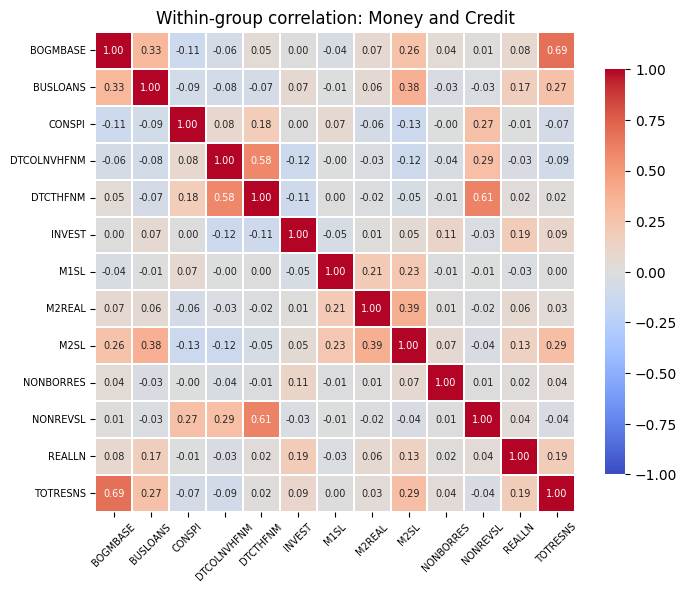

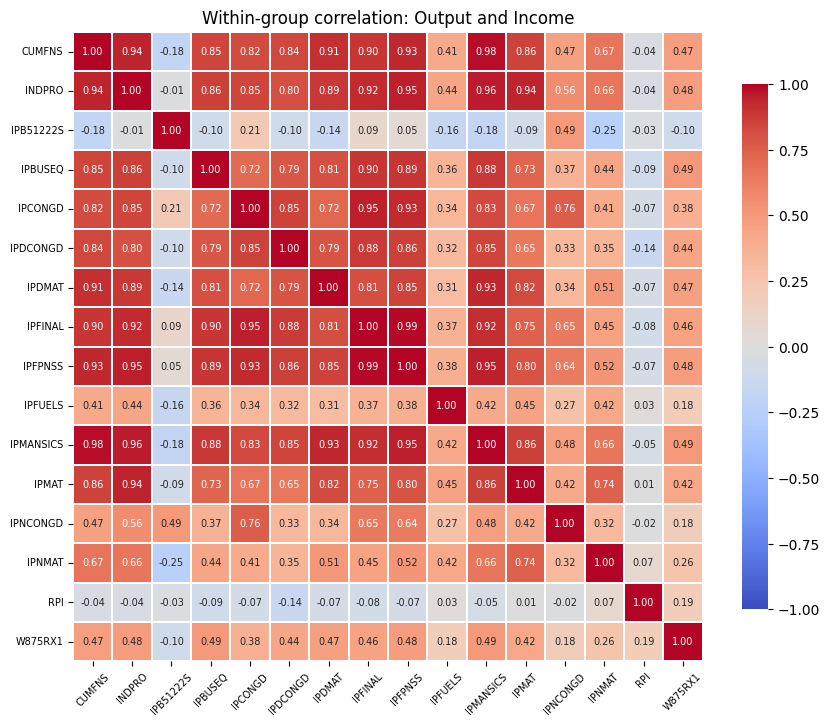

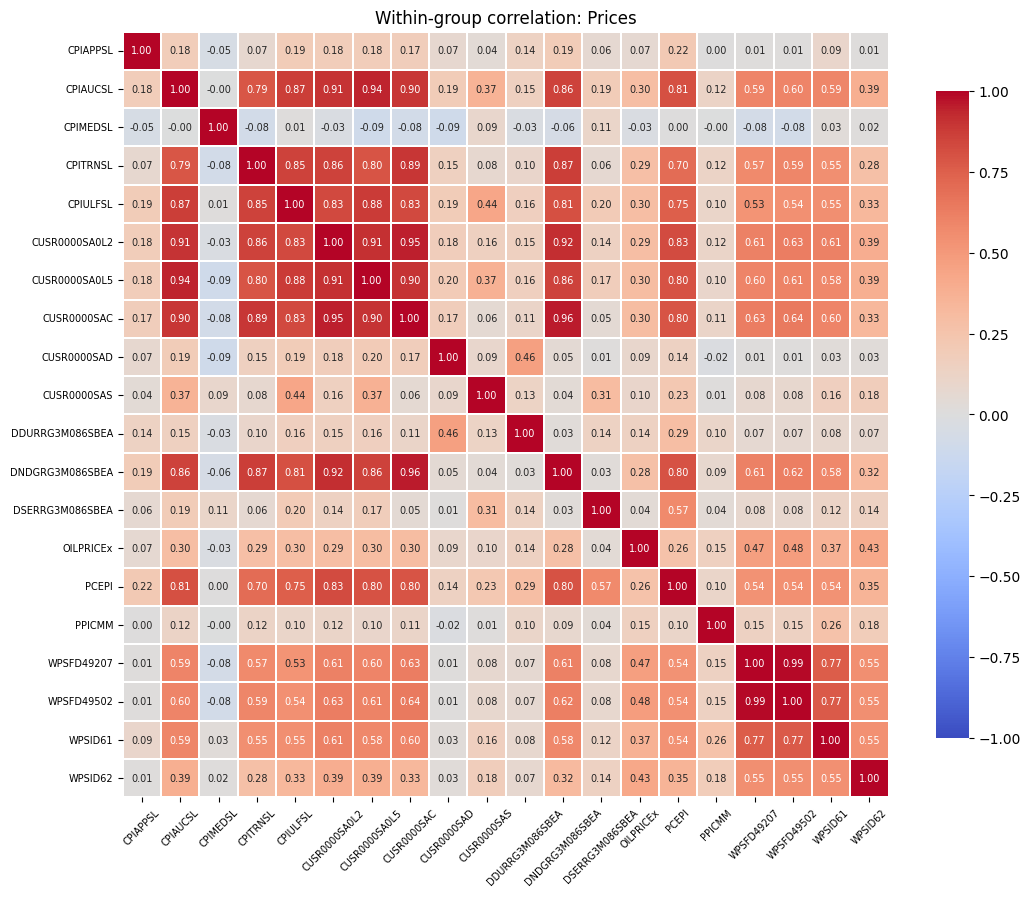

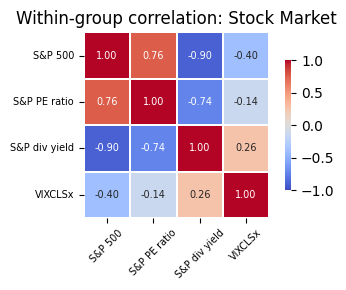

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fred = X["fred"].copy()
group_level = 0

# Standardize each series
fred_std = fred.copy()
for g in fred.columns.get_level_values(group_level).unique():
    cols = fred.columns[fred.columns.get_level_values(group_level) == g]
    block = fred.loc[:, cols]
    mu = block.mean(axis=0)
    sd = block.std(axis=0, ddof=0).replace(0, np.nan)
    fred_std.loc[:, cols] = (block - mu) / sd
fred_std = fred_std.fillna(0.0)

groups = fred_std.columns.get_level_values(group_level).unique()

for g in groups:
    block = fred_std.loc[:, fred_std.columns.get_level_values(group_level) == g]
    # Drop the group level so series names are readable
    block.columns = block.columns.droplevel(group_level)
    corr = block.corr()
    
    n = len(corr)
    fig, ax = plt.subplots(figsize=(max(4, n * 0.55), max(3, n * 0.5)))
    sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
                annot=n <= 20, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.3, square=True, cbar_kws={"shrink": 0.7})
    ax.set_title(f"Within-group correlation: {g}", fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)
    plt.tight_layout()
    plt.show()

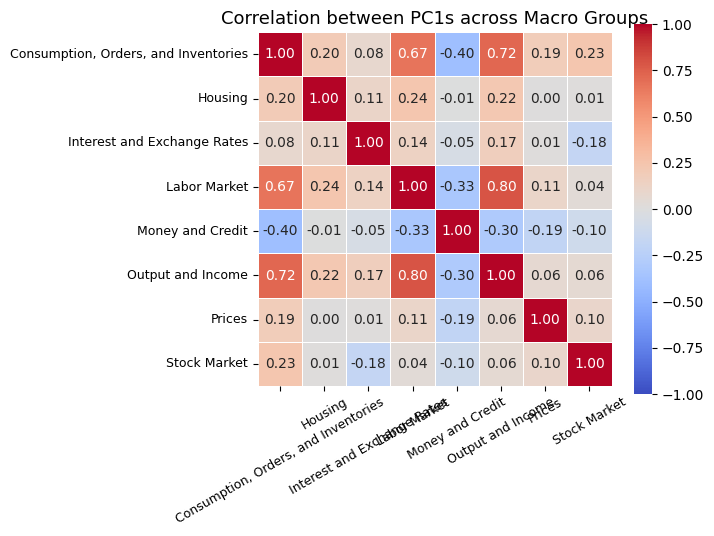

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from textwrap import fill

fred = X["fred"].copy()
group_level = 0

# Standardize each series
fred_std = fred.copy()
for g in fred.columns.get_level_values(group_level).unique():
    cols = fred.columns[fred.columns.get_level_values(group_level) == g]
    block = fred.loc[:, cols]
    mu = block.mean(axis=0)
    sd = block.std(axis=0, ddof=0).replace(0, np.nan)
    fred_std.loc[:, cols] = (block - mu) / sd
fred_std = fred_std.fillna(0.0)

# Extract PC1 for each macro group
pc1_dict = {}
for g in fred_std.columns.get_level_values(group_level).unique():
    block = fred_std.loc[:, fred_std.columns.get_level_values(group_level) == g].values
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(block).flatten()
    pc1_dict[g] = pc1

pc1_df = pd.DataFrame(pc1_dict, index=fred_std.index)

# Correlation heatmap between PC1s
corr = pc1_df.corr()
n_groups = len(corr)
max_label_len = max(len(str(c)) for c in corr.columns)
fig_w = max(7.5, 0.85 * n_groups + 0.09 * max_label_len * n_groups)
fig_h = max(5.5, 0.9 * n_groups)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    square=True,
    cbar_kws={"shrink": 0.75}
 )

wrapped_labels = [fill(str(lbl), width=18) for lbl in corr.columns]
ax.set_xticklabels(wrapped_labels, rotation=35, ha="right", rotation_mode="anchor", fontsize=9)
ax.set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
ax.set_title("Correlation between PC1s across Macro Groups", fontsize=13)
plt.tight_layout()
plt.show()

# Correlation between level, slope and curvature:

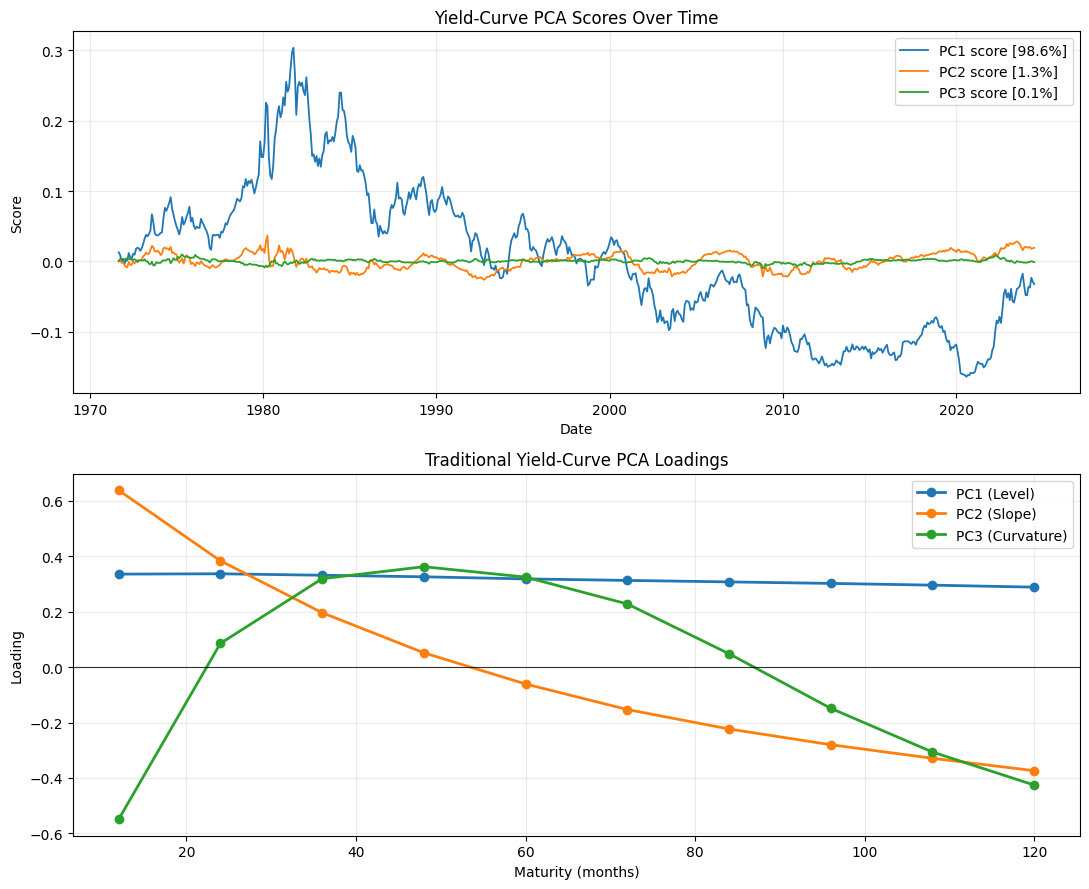

In [14]:
# Traditional level-slope-curvature PCA with score time series + loadings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Use the yield curve cross-section (standard in level/slope/curvature PCA)
curve_df = X['yields'].copy()

# Extract maturity labels robustly and sort maturities ascending
if isinstance(curve_df.columns, pd.MultiIndex):
    maturity_raw = curve_df.columns.get_level_values(-1).astype(str)
else:
    maturity_raw = curve_df.columns.astype(str)

maturity_num = pd.to_numeric(maturity_raw, errors='coerce')
valid = ~maturity_num.isna()
maturity_num = maturity_num[valid]
curve_df = curve_df.loc[:, valid]

sort_idx = np.argsort(maturity_num.values)
maturity_sorted = maturity_num.values[sort_idx]
curve_sorted = curve_df.iloc[:, sort_idx]

# PCA on sorted curve data
pca = PCA(n_components=3)
scores = pca.fit_transform(curve_sorted.values)
loadings = pca.components_.copy()

# Sign normalization for traditional interpretation
if np.mean(loadings[0]) < 0:
    loadings[0] *= -1
    scores[:, 0] *= -1
if loadings[1, 0] < loadings[1, -1]:
    loadings[1] *= -1
    scores[:, 1] *= -1
mid = len(maturity_sorted) // 2
if loadings[2, mid] < 0:
    loadings[2] *= -1
    scores[:, 2] *= -1

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

# Top: score time series
score_labels = [
    f'PC1 score [{pca.explained_variance_ratio_[0]*100:.1f}%]',
    f'PC2 score [{pca.explained_variance_ratio_[1]*100:.1f}%]',
    f'PC3 score [{pca.explained_variance_ratio_[2]*100:.1f}%]'
 ]
for i in range(3):
    sns.lineplot(x=curve_sorted.index, y=scores[:, i], ax=axes[0], label=score_labels[i], linewidth=1.3)
axes[0].set_title('Yield-Curve PCA Scores Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Score')
axes[0].grid(alpha=0.25)
axes[0].legend()

# Bottom: traditional loading curves
loading_labels = [
    'PC1 (Level)',
    'PC2 (Slope)',
    'PC3 (Curvature)'
 ]
for i in range(3):
    axes[1].plot(maturity_sorted, loadings[i], marker='o', linewidth=2.0, label=loading_labels[i])
axes[1].axhline(0.0, color='black', linewidth=0.8, alpha=0.8)
axes[1].set_title('Traditional Yield-Curve PCA Loadings')
axes[1].set_xlabel('Maturity (months)')
axes[1].set_ylabel('Loading')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()